# Building a model with Random Forest

In [1]:
import numpy as np
import pandas as pd

In [2]:
atm = pd.read_csv(r'Dataset/ATM_Maintenance_Cleaned.csv', parse_dates=['Date'])
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,Idukki,Hospital,NCR,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,Kozhikode,Railway,Diebold,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,Malappuram,Airport,Diebold,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,Alappuzha,Rural,Diebold,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,Thrissur,Hospital,NCR,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,Kottayam,Airport,Diebold,8.1,595,29,69.0,0,...,58,177,0,79,3,5,0,0,1,1
49996,2025-12-23,ATM229,Kollam,Airport,Hitachi,7.3,578,11,85.0,1,...,67,41,3,77,3,70,6,1,0,0
49997,2025-12-24,ATM247,Thrissur,Hospital,Diebold,6.2,656,1,35.0,0,...,65,64,0,89,0,43,4,2,0,0
49998,2025-12-25,ATM184,Kottayam,Railway,NCR,1.9,471,19,62.0,0,...,71,114,0,100,1,0,2,3,1,1


In [3]:
atm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    50000 non-null  datetime64[ns]
 1   ATM_ID                  50000 non-null  object        
 2   District                50000 non-null  object        
 3   Location_Type           50000 non-null  object        
 4   Manufacturer            50000 non-null  object        
 5   ATM_Age_Yrs             50000 non-null  float64       
 6   Daily_Transactions      50000 non-null  int64         
 7   Failed_Transactions     50000 non-null  int64         
 8   Cash_Remaining_Pct      50000 non-null  float64       
 9   Cash_Loaded_Today       50000 non-null  int64         
 10  CardReader_Errors       50000 non-null  int64         
 11  CashDispenser_Errors    50000 non-null  int64         
 12  Cash_Jams               50000 non-null  int64 

In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
le = LabelEncoder()

In [6]:
atm['District'] = le.fit_transform(atm['District'])
atm['Location_Type'] = le.fit_transform(atm['Location_Type'])
atm['Manufacturer'] = le.fit_transform(atm['Manufacturer'])

In [7]:
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,2,2,2,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,6,4,0,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,7,0,0,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,0,5,0,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,9,2,2,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,5,0,0,8.1,595,29,69.0,0,...,58,177,0,79,3,5,0,0,1,1
49996,2025-12-23,ATM229,4,0,1,7.3,578,11,85.0,1,...,67,41,3,77,3,70,6,1,0,0
49997,2025-12-24,ATM247,9,2,0,6.2,656,1,35.0,0,...,65,64,0,89,0,43,4,2,0,0
49998,2025-12-25,ATM184,5,4,2,1.9,471,19,62.0,0,...,71,114,0,100,1,0,2,3,1,1


In [8]:
X = atm.drop(columns=['Date', 'ATM_ID', 'Failure_Next_48H'])
y = atm['Failure_Next_48H']

In [9]:
X

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code
0,2,2,2,1.2,429,15,69.0,0,2,3,...,29,52,46,0,78,2,29,4,1,5
1,6,4,0,1.9,343,6,43.0,0,0,3,...,50,45,10,0,92,3,58,1,0,2
2,7,0,0,2.5,285,10,78.0,0,2,1,...,65,53,66,2,88,0,63,0,0,0
3,0,5,0,4.6,488,22,39.0,0,2,2,...,84,67,95,1,68,1,54,0,0,5
4,9,2,2,8.7,736,25,57.0,0,2,2,...,74,54,56,3,97,4,57,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5,0,0,8.1,595,29,69.0,0,1,3,...,32,58,177,0,79,3,5,0,0,1
49996,4,0,1,7.3,578,11,85.0,1,2,2,...,12,67,41,3,77,3,70,6,1,0
49997,9,2,0,6.2,656,1,35.0,0,1,0,...,49,65,64,0,89,0,43,4,2,0
49998,5,4,2,1.9,471,19,62.0,0,2,3,...,21,71,114,0,100,1,0,2,3,1


In [10]:
y

0        1
1        1
2        0
3        1
4        0
        ..
49995    1
49996    0
49997    0
49998    1
49999    0
Name: Failure_Next_48H, Length: 50000, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code
39087,0,1,2,5.4,601,17,37.0,0,0,3,...,25,65,72,1,100,0,5,1,2,5
30893,8,0,2,1.3,613,19,27.0,0,2,1,...,29,59,62,0,81,3,19,3,2,0
45278,5,4,0,9.5,337,8,49.0,1,1,3,...,33,67,33,4,90,3,50,0,0,5
16398,6,5,0,8.4,157,3,42.0,1,2,2,...,29,58,16,0,93,2,36,0,0,0
13653,8,0,0,1.9,422,15,76.0,0,0,3,...,26,57,82,1,83,0,41,4,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,9,4,0,4.8,346,1,45.0,0,1,0,...,64,61,35,0,99,4,24,0,1,0
44732,1,0,2,6.3,25,0,37.0,0,0,3,...,39,62,31,3,86,1,52,0,2,1
38158,7,5,0,9.3,699,9,79.0,0,1,3,...,67,83,74,0,100,0,44,0,0,2
860,7,1,1,9.2,336,0,46.0,1,2,3,...,53,39,39,0,87,0,65,0,0,1


In [14]:
X_test

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code
33553,0,4,1,2.2,493,14,55.0,1,0,0,...,35,74,68,2,80,4,57,1,3,0
9427,0,0,1,5.3,640,8,75.0,0,0,3,...,53,56,21,1,92,3,45,0,0,2
199,9,2,1,2.4,447,20,50.0,1,2,1,...,38,54,110,0,89,0,7,0,0,0
12447,6,2,2,5.8,490,11,28.0,0,1,1,...,40,50,17,2,100,1,17,2,0,0
39489,4,0,1,1.3,481,4,72.0,1,0,1,...,24,68,80,1,86,0,33,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28567,2,5,1,4.9,479,4,56.0,0,1,2,...,48,55,61,2,96,3,40,1,0,0
25079,4,0,2,5.6,425,0,62.0,0,2,0,...,35,50,42,0,98,1,68,6,4,6
18707,1,4,1,8.8,281,9,43.0,0,1,3,...,35,56,133,2,77,0,22,0,2,3
15200,8,5,1,3.4,376,7,86.0,0,1,2,...,47,72,59,1,83,0,17,0,0,0


In [15]:
y_train

39087    1
30893    0
45278    1
16398    0
13653    1
        ..
11284    0
44732    1
38158    1
860      1
15795    1
Name: Failure_Next_48H, Length: 40000, dtype: int64

In [16]:
y_test

33553    0
9427     1
199      0
12447    0
39489    0
        ..
28567    0
25079    1
18707    1
15200    0
5857     0
Name: Failure_Next_48H, Length: 10000, dtype: int64

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [19]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 1, 0, 0], shape=(10000,))

In [21]:
from sklearn.metrics import accuracy_score, classification_report

In [22]:
accuracy=accuracy_score(y_test,y_pred)
print('Accuracy Score: ',accuracy)

Accuracy Score:  1.0


In [23]:
cls_rep=classification_report(y_test, y_pred)
print('\n Classification Report: \n',cls_rep)


 Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5669
           1       1.00      1.00      1.00      4331

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



### 1. Class 0 (No Failure)
- The model achieved 100% precision, indicating that every ATM predicted as No Failure was classified correctly.
- The recall of 100% shows that all actual non-failure cases were successfully identified.
- The F1-score of 1.00 reflects perfect classification performance for this class.
### 2. Class 1 (Failure)
- The model achieved 100% precision, meaning every ATM predicted to fail actually belonged to the failure class.
- The recall of 100% indicates that the model detected every actual failure without missing any cases.
- The F1-score of 1.00 confirms perfect prediction performance for ATM failures.

In [24]:
importances = model.feature_importances_
feature_names = X.columns

In [25]:
importances

array([1.67454809e-04, 1.17488740e-04, 8.02647599e-05, 3.40385092e-04,
       4.71325914e-04, 2.60095518e-04, 3.48930237e-04, 4.29535159e-05,
       6.55127339e-05, 2.32508529e-01, 4.58320074e-05, 2.29545011e-01,
       3.30070451e-04, 3.93060167e-04, 3.17461225e-04, 3.63687836e-04,
       1.12214643e-03, 9.69519003e-05, 3.15278807e-04, 1.34781312e-04,
       3.26763795e-04, 1.40588016e-04, 1.16449426e-04, 5.32348977e-01])

In [26]:
feature_names

Index(['District', 'Location_Type', 'Manufacturer', 'ATM_Age_Yrs',
       'Daily_Transactions', 'Failed_Transactions', 'Cash_Remaining_Pct',
       'Cash_Loaded_Today', 'CardReader_Errors', 'CashDispenser_Errors',
       'Cash_Jams', 'Printer_Errors', 'Paper_Remaining_Pct', 'CPU_Temp_C',
       'CPU_Usage_Pct', 'Memory_Usage_Pct', 'Network_Latency_ms',
       'Network_Drops', 'UPS_Battery_Pct', 'Power_Outages_7D',
       'Days_Since_Maintenance', 'Previous_Failures_90D',
       'Customer_Complaints_7D', 'Failure_Code'],
      dtype='object')

In [27]:
import matplotlib.pyplot as plt

<BarContainer object of 24 artists>

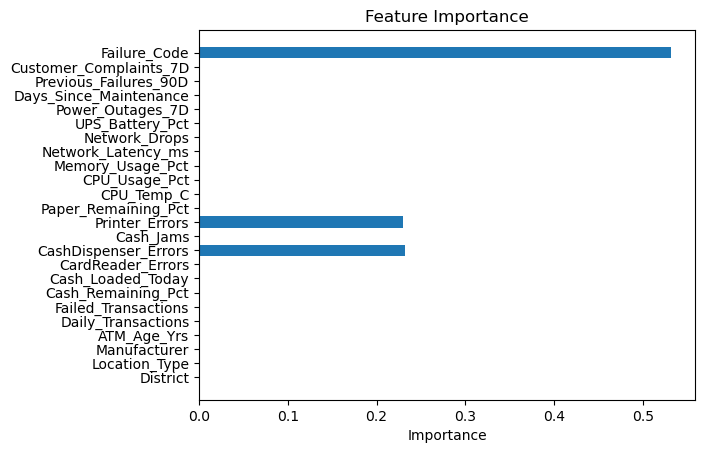

In [28]:
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.barh(feature_names,importances)

# Predicting whether each ATM will fail in the next 48 hours or not and then separating the ATMs into failing and non-failing groups.

In [29]:
# Predict Failure_Next_48H for all ATMs
all_predictions = model.predict(X)

# Add predictions to the original dataset
atm_predictions = atm.copy()
atm_predictions['Predicted_Failure_Next_48H'] = all_predictions

atm_predictions

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H
0,2025-01-01,ATM058,2,2,2,1.2,429,15,69.0,0,...,46,0,78,2,29,4,1,5,1,1
1,2025-01-02,ATM173,6,4,0,1.9,343,6,43.0,0,...,10,0,92,3,58,1,0,2,1,1
2,2025-01-03,ATM187,7,0,0,2.5,285,10,78.0,0,...,66,2,88,0,63,0,0,0,0,0
3,2025-01-04,ATM256,0,5,0,4.6,488,22,39.0,0,...,95,1,68,1,54,0,0,5,1,1
4,2025-01-05,ATM284,9,2,2,8.7,736,25,57.0,0,...,56,3,97,4,57,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,5,0,0,8.1,595,29,69.0,0,...,177,0,79,3,5,0,0,1,1,1
49996,2025-12-23,ATM229,4,0,1,7.3,578,11,85.0,1,...,41,3,77,3,70,6,1,0,0,0
49997,2025-12-24,ATM247,9,2,0,6.2,656,1,35.0,0,...,64,0,89,0,43,4,2,0,0,0
49998,2025-12-25,ATM184,5,4,2,1.9,471,19,62.0,0,...,114,0,100,1,0,2,3,1,1,1


## 1. Extract ATMs predicted to fail

In [30]:
failing_atms = atm_predictions[
    atm_predictions['Predicted_Failure_Next_48H'] == 1]

failing_atms

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H
0,2025-01-01,ATM058,2,2,2,1.2,429,15,69.0,0,...,46,0,78,2,29,4,1,5,1,1
1,2025-01-02,ATM173,6,4,0,1.9,343,6,43.0,0,...,10,0,92,3,58,1,0,2,1,1
3,2025-01-04,ATM256,0,5,0,4.6,488,22,39.0,0,...,95,1,68,1,54,0,0,5,1,1
6,2025-01-07,ATM109,5,0,0,9.4,459,16,24.0,1,...,63,2,100,2,48,5,1,2,1,1
12,2025-01-13,ATM142,2,3,1,1.4,402,19,64.0,0,...,97,1,77,0,67,1,5,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49990,2025-12-17,ATM143,8,1,0,5.3,593,5,40.0,0,...,15,3,69,3,10,0,0,3,1,1
49993,2025-12-20,ATM262,3,1,1,6.8,374,12,64.0,0,...,71,0,94,4,81,4,2,3,1,1
49994,2025-12-21,ATM210,1,0,0,4.9,115,0,91.0,0,...,15,1,98,4,0,0,2,3,1,1
49995,2025-12-22,ATM153,5,0,0,8.1,595,29,69.0,0,...,177,0,79,3,5,0,0,1,1,1


In [34]:
failing_atms[['Date', 'ATM_ID', 'ATM_Age_Yrs', 'CashDispenser_Errors', 'Printer_Errors',  'Failure_Code',
              'Days_Since_Maintenance', 'Predicted_Failure_Next_48H']]

,Date,ATM_ID,ATM_Age_Yrs,CashDispenser_Errors,Printer_Errors,Failure_Code,Days_Since_Maintenance,Predicted_Failure_Next_48H
0,2025-01-01,ATM058,1.2,3,0,5,29,1
1,2025-01-02,ATM173,1.9,3,3,2,58,1
3,2025-01-04,ATM256,4.6,2,3,5,54,1
6,2025-01-07,ATM109,9.4,2,3,2,48,1
12,2025-01-13,ATM142,1.4,3,0,1,67,1
...,...,...,...,...,...,...,...,...
49990,2025-12-17,ATM143,5.3,1,3,3,10,1
49993,2025-12-20,ATM262,6.8,3,3,3,81,1
49994,2025-12-21,ATM210,4.9,3,0,3,0,1
49995,2025-12-22,ATM153,8.1,3,2,1,5,1


## 2. Extract ATMs predicted NOT to fail

In [35]:
non_failing_atms = atm_predictions[
    atm_predictions['Predicted_Failure_Next_48H'] == 0]

non_failing_atms

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H
2,2025-01-03,ATM187,7,0,0,2.5,285,10,78.0,0,...,66,2,88,0,63,0,0,0,0,0
4,2025-01-05,ATM284,9,2,2,8.7,736,25,57.0,0,...,56,3,97,4,57,0,0,0,0,0
5,2025-01-06,ATM272,5,5,1,9.3,260,7,45.0,0,...,83,4,95,1,24,0,1,0,0,0
7,2025-01-08,ATM068,6,3,2,7.5,396,17,41.0,1,...,102,3,92,0,31,0,0,0,0,0
8,2025-01-09,ATM230,8,2,0,2.3,531,23,75.0,0,...,32,1,85,1,0,5,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49991,2025-12-18,ATM106,6,1,1,6.1,451,1,69.0,0,...,93,5,91,0,73,0,2,0,0,0
49992,2025-12-19,ATM205,0,4,1,8.1,584,22,71.0,0,...,43,0,94,1,41,0,1,0,0,0
49996,2025-12-23,ATM229,4,0,1,7.3,578,11,85.0,1,...,41,3,77,3,70,6,1,0,0,0
49997,2025-12-24,ATM247,9,2,0,6.2,656,1,35.0,0,...,64,0,89,0,43,4,2,0,0,0


In [36]:
non_failing_atms[['Date', 'ATM_ID', 'ATM_Age_Yrs', 'CashDispenser_Errors', 'Printer_Errors',  'Failure_Code',
              'Days_Since_Maintenance', 'Predicted_Failure_Next_48H']]

,Date,ATM_ID,ATM_Age_Yrs,CashDispenser_Errors,Printer_Errors,Failure_Code,Days_Since_Maintenance,Predicted_Failure_Next_48H
2,2025-01-03,ATM187,2.5,1,1,0,63,0
4,2025-01-05,ATM284,8.7,2,2,0,57,0
5,2025-01-06,ATM272,9.3,1,1,0,24,0
7,2025-01-08,ATM068,7.5,1,0,0,31,0
8,2025-01-09,ATM230,2.3,0,0,0,0,0
...,...,...,...,...,...,...,...,...
49991,2025-12-18,ATM106,6.1,1,2,0,73,0
49992,2025-12-19,ATM205,8.1,0,0,0,41,0
49996,2025-12-23,ATM229,7.3,2,1,0,70,0
49997,2025-12-24,ATM247,6.2,0,2,0,43,0


In [37]:
print("Number of ATMs predicted to fail:",
      len(failing_atms))

print("Number of ATMs predicted not to fail:",
      len(non_failing_atms))

Number of ATMs predicted to fail: 21767
Number of ATMs predicted not to fail: 28233


## Probability of Failure

In [39]:
# Probability of failure for all ATMs
failure_probability = model.predict_proba(X)[:, 1]

atm_predictions['Failure_Probability'] = failure_probability

In [40]:
atm_predictions = atm_predictions.sort_values(
    by='Failure_Probability',
    ascending=False)

atm_predictions

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H,Predicted_Failure_Next_48H,Failure_Probability
0,2025-01-01,ATM058,2,2,2,1.2,429,15,69.0,0,...,0,78,2,29,4,1,5,1,1,1.0
19261,2025-10-09,ATM228,6,4,0,4.0,540,15,57.0,0,...,1,100,1,23,3,0,5,1,1,1.0
39588,2025-06-18,ATM085,3,4,1,7.0,597,8,43.0,0,...,2,100,3,52,0,0,1,1,1,1.0
19257,2025-10-05,ATM088,2,1,2,5.2,378,6,43.0,0,...,1,90,0,0,1,2,2,1,1,1.0
19256,2025-10-04,ATM280,6,4,0,8.8,254,5,36.0,0,...,0,89,1,0,0,0,5,1,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21574,2025-02-09,ATM012,1,2,1,9.7,806,38,40.0,0,...,3,79,0,26,0,3,0,0,0,0.0
21572,2025-02-07,ATM296,1,0,0,5.1,614,7,62.0,0,...,0,80,1,73,0,1,0,0,0,0.0
21571,2025-02-06,ATM213,0,1,0,5.2,570,6,62.0,0,...,0,80,4,21,0,0,0,0,0,0.0
21568,2025-02-03,ATM002,6,5,0,4.4,625,21,83.0,0,...,0,81,0,69,1,2,0,0,0,0.0


| Part                               | Verdict                                                  |
| ---------------------------------- | -------------------------------------------------------- |
| Random Forest implementation       | ✅ Correct                                                |
| Train/test split code              | ✅ Works                                                  |
| Evaluation code                    | ✅ Correct                                                |
| 100% accuracy                      | ⚠️ Suspiciously high                                     |
| All-record prediction              | ⚠️ Technically works, but not a proper future prediction |
| Separating failing/non-failing     | ✅ Correct                                                |
| Failure probability                | ✅ Correct approach                                       |
| `Failure_Code` as predictor        | 🚨 Likely leakage                                        |
| Random split for future prediction | ⚠️ Not ideal                                             |
| Latest record per ATM              | **Recommended**                                          |
| Claiming 100% future accuracy      | ❌ Don't claim this                                       |
